In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
import pandas as pd

df = pd.read_csv('/content/data.csv', encoding='latin1')
df.head()

/tmp/ipykernel_32807/1111892049.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/data.csv', encoding='latin1')


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [ ]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   stn_code                     291665 non-null  object 
 1   sampling_date                435739 non-null  object 
 2   state                        435742 non-null  object 
 3   location                     435739 non-null  object 
 4   agency                       286261 non-null  object 
 5   type                         430349 non-null  object 
 6   so2                          401096 non-null  float64
 7   no2                          419509 non-null  float64
 8   rspm                         395520 non-null  float64
 9   spm                          198355 non-null  float64
 10  location_monitoring_station  408251 non-null  object 
 11  pm2_5                        9314 non-null    float64
 12  date                         435735 non-null  object 
dtyp

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [ ]:
# Convert date column properly
df['sampling_date'] = pd.to_datetime(df['sampling_date'], errors='coerce')

# Drop duplicate 'date' column (you already have sampling_date)
df.drop(columns=['date'], inplace=True)

# Handle missing values
df = df.dropna(subset=['so2', 'no2', 'rspm', 'spm'])

# pm2_5 has too many missing values → drop it
df.drop(columns=['pm2_5'], inplace=True)

# Fill categorical missing values
df['stn_code'].fillna('Unknown', inplace=True)
df['agency'].fillna('Unknown', inplace=True)

# Final check
df.isnull().sum()

/tmp/ipykernel_32807/318371950.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['sampling_date'] = pd.to_datetime(df['sampling_date'], errors='coerce')
/tmp/ipykernel_32807/318371950.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['pm2_5'], inplace=True)
/tmp/ipykernel_32807/318371950.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

,0
stn_code,0
sampling_date,21904
state,0
location,0
agency,0
type,0
so2,0
no2,0
rspm,0
spm,0


In [ ]:
# Extract year & month
df['year'] = df['sampling_date'].dt.year
df['month'] = df['sampling_date'].dt.month

/tmp/ipykernel_32807/824965050.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['sampling_date'].dt.year
/tmp/ipykernel_32807/824965050.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['sampling_date'].dt.month


In [ ]:
df['AQI'] = (df['so2'] + df['no2'] + df['rspm'] + df['spm']) / 4

/tmp/ipykernel_32807/2238584943.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AQI'] = (df['so2'] + df['no2'] + df['rspm'] + df['spm']) / 4


In [ ]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df['AQI_Category'] = df['AQI'].apply(categorize_aqi)

/tmp/ipykernel_32807/480773784.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AQI_Category'] = df['AQI'].apply(categorize_aqi)


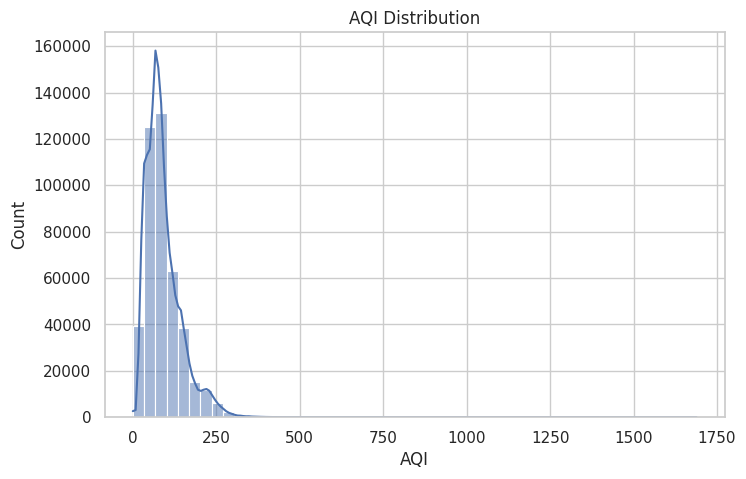

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['AQI'], bins=50, kde=True)
plt.title("AQI Distribution")
plt.show()

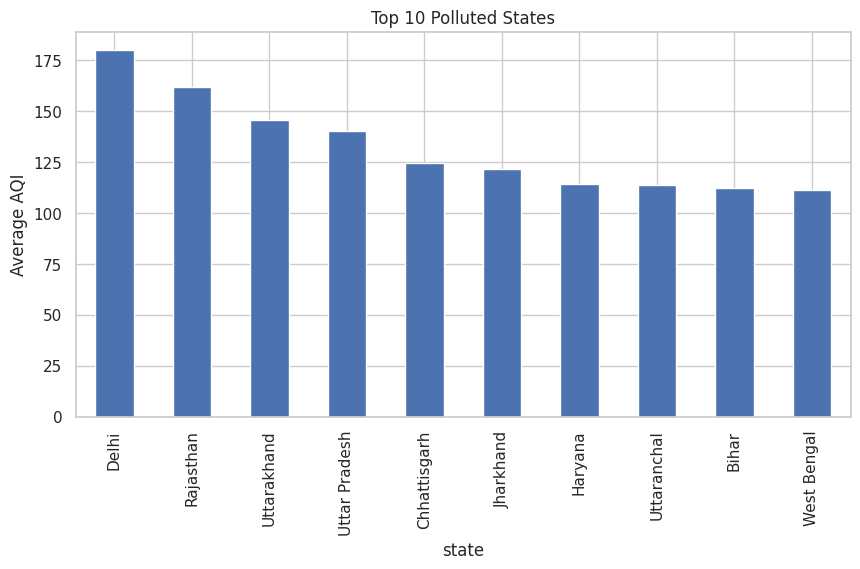

In [ ]:
top_states = df.groupby('state')['AQI'].mean().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Polluted States")
plt.ylabel("Average AQI")
plt.show()

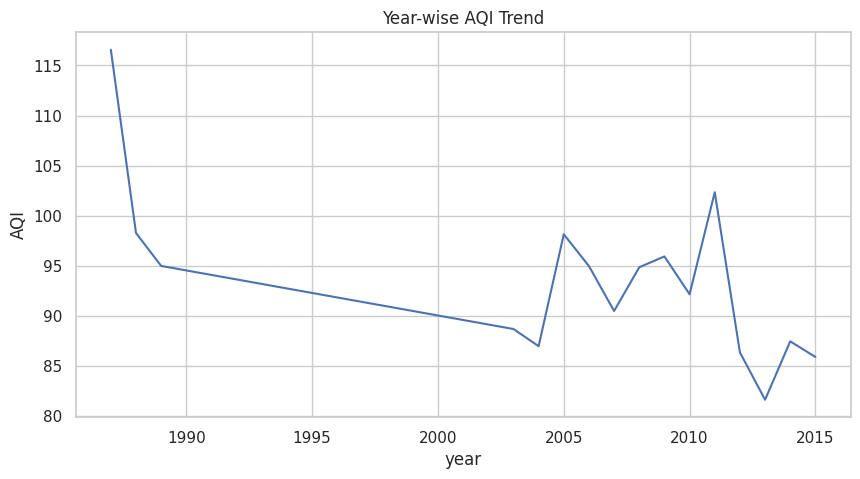

In [ ]:
yearly = df.groupby('year')['AQI'].mean()

yearly.plot(figsize=(10,5))
plt.title("Year-wise AQI Trend")
plt.ylabel("AQI")
plt.show()

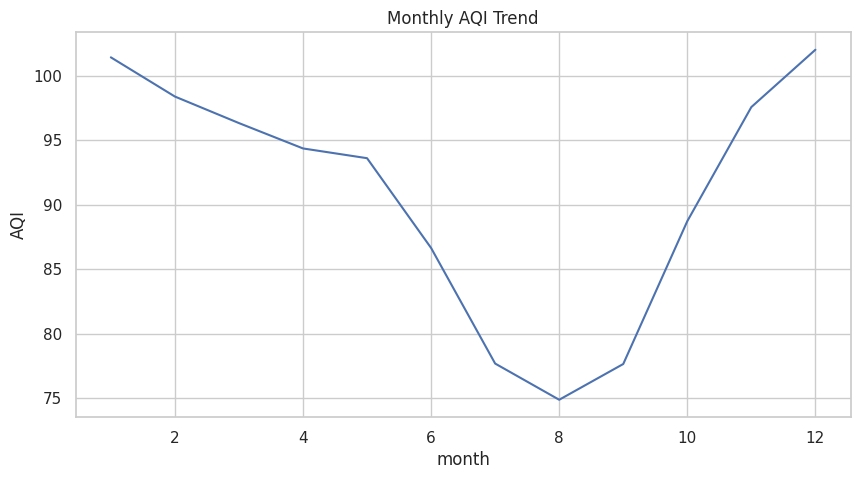

In [ ]:
monthly = df.groupby('month')['AQI'].mean()

monthly.plot(figsize=(10,5))
plt.title("Monthly AQI Trend")
plt.ylabel("AQI")
plt.show()

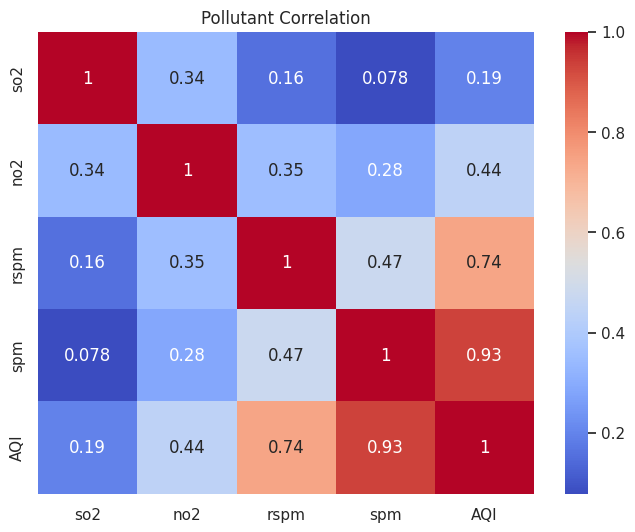

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['so2','no2','rspm','spm','AQI']].corr(), annot=True, cmap='coolwarm')
plt.title("Pollutant Correlation")
plt.show()

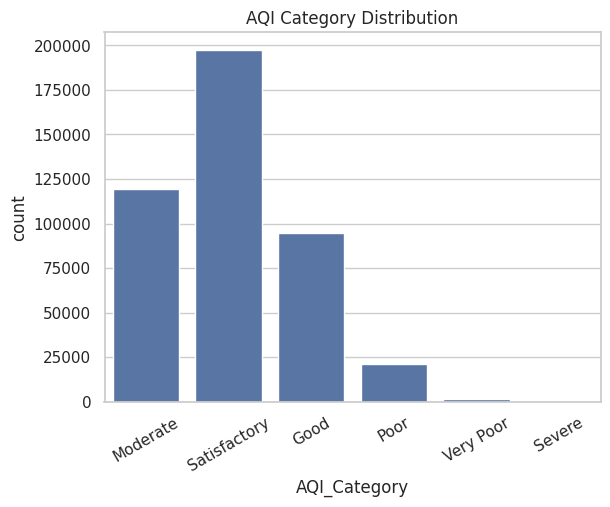

In [ ]:
sns.countplot(x='AQI_Category', data=df)
plt.title("AQI Category Distribution")
plt.xticks(rotation=30)
plt.show()

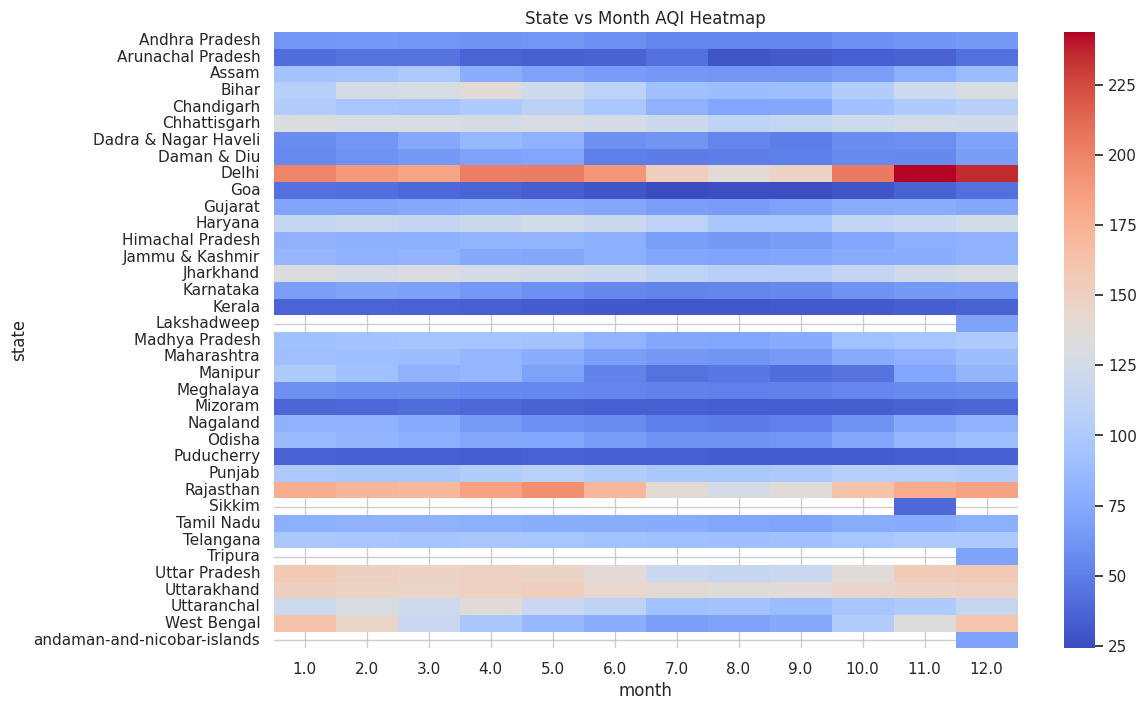

In [ ]:
pivot_table = df.pivot_table(values='AQI', index='state', columns='month', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("State vs Month AQI Heatmap")
plt.show()

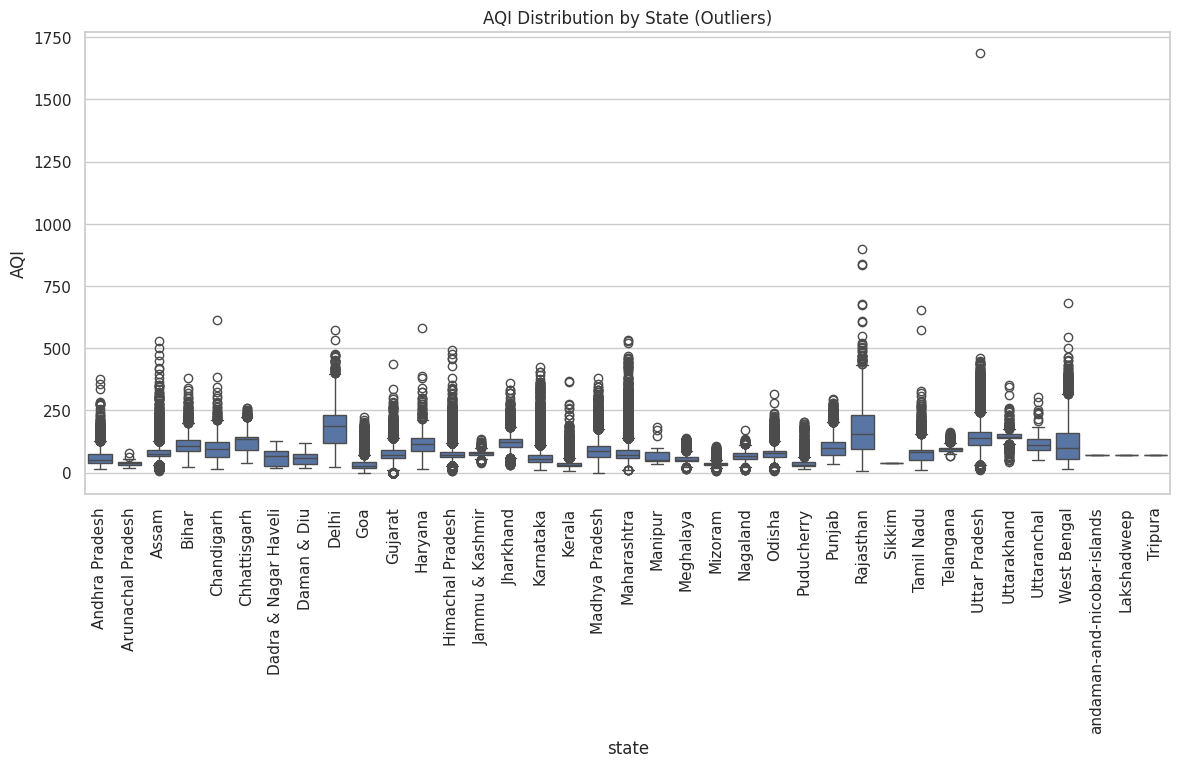

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(x='state', y='AQI', data=df)
plt.xticks(rotation=90)
plt.title("AQI Distribution by State (Outliers)")
plt.show()

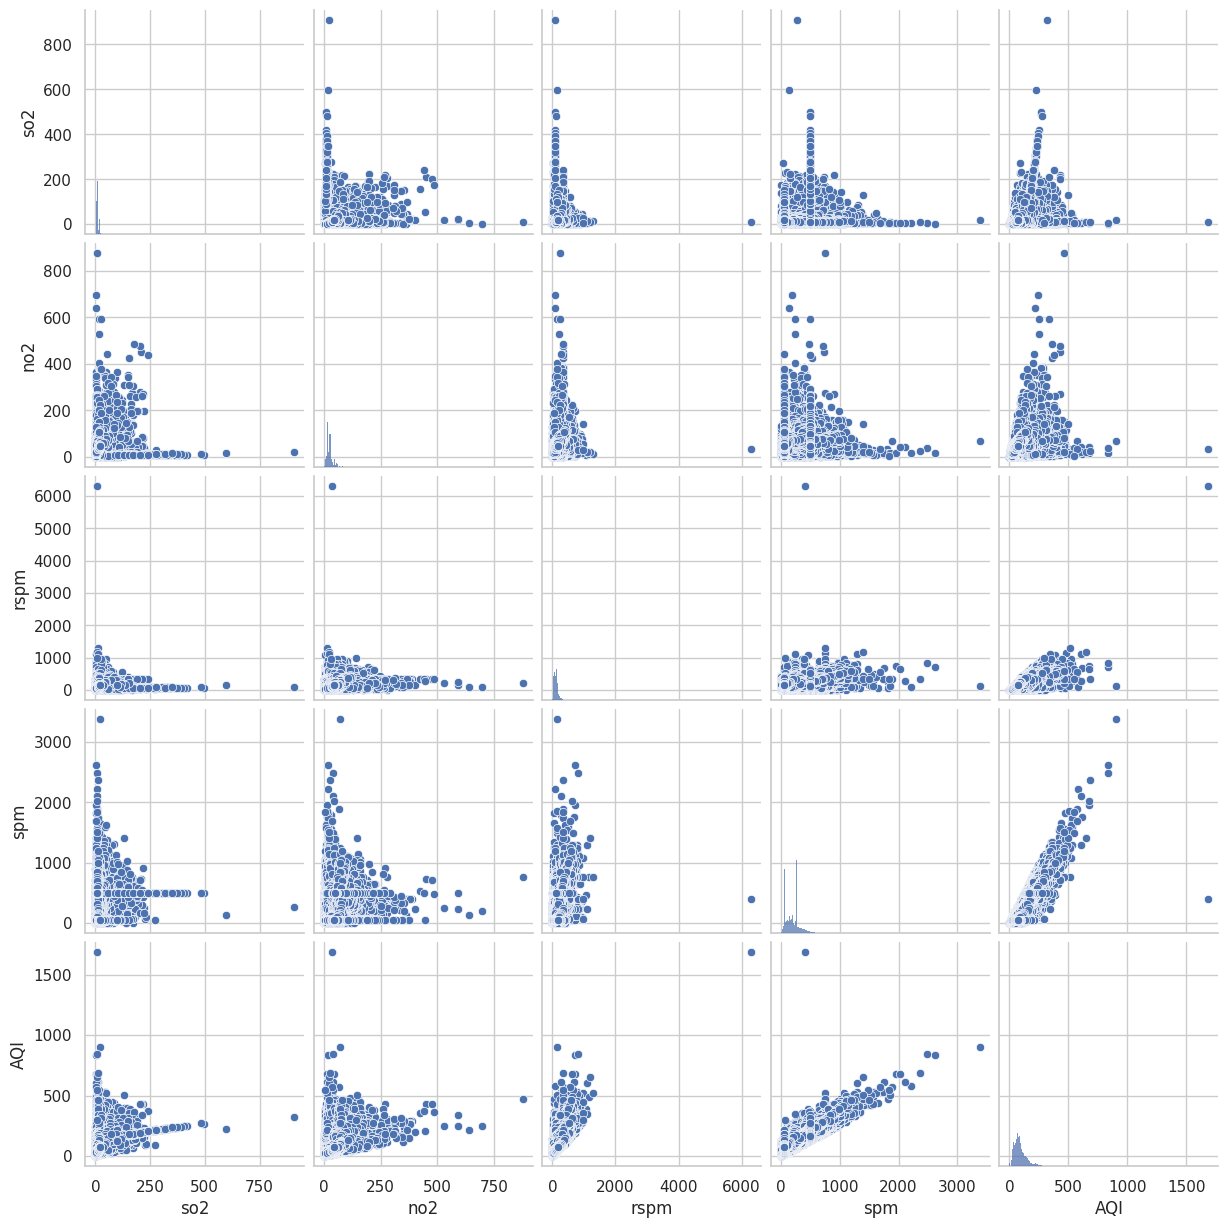

In [ ]:
sns.pairplot(df[['so2','no2','rspm','spm','AQI']])
plt.show()

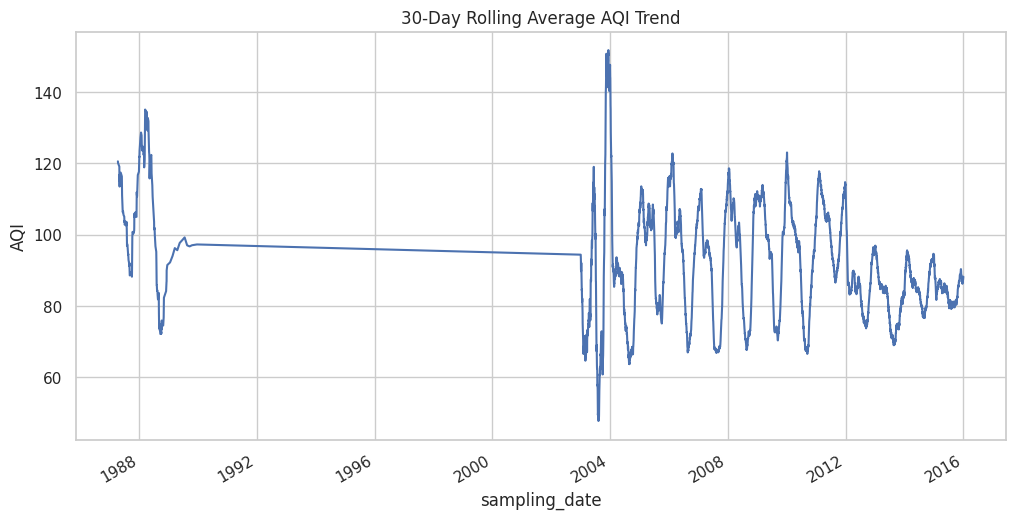

In [ ]:
df_sorted = df.sort_values('sampling_date')

rolling_avg = df_sorted.groupby('sampling_date')['AQI'].mean().rolling(window=30).mean()

plt.figure(figsize=(12,6))
rolling_avg.plot()
plt.title("30-Day Rolling Average AQI Trend")
plt.ylabel("AQI")
plt.show()

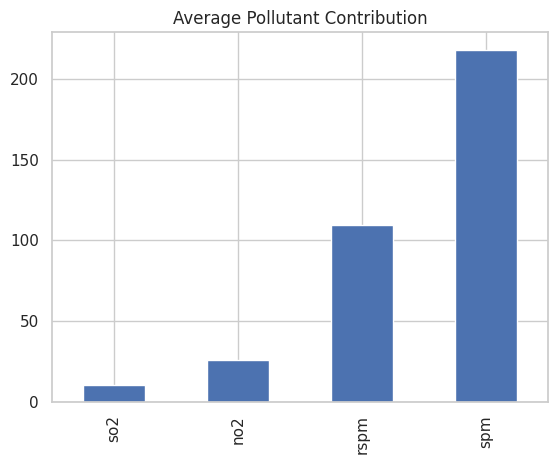

In [ ]:
df_sample = df[['so2','no2','rspm','spm']].mean()

df_sample.plot(kind='bar', stacked=True)
plt.title("Average Pollutant Contribution")
plt.show()

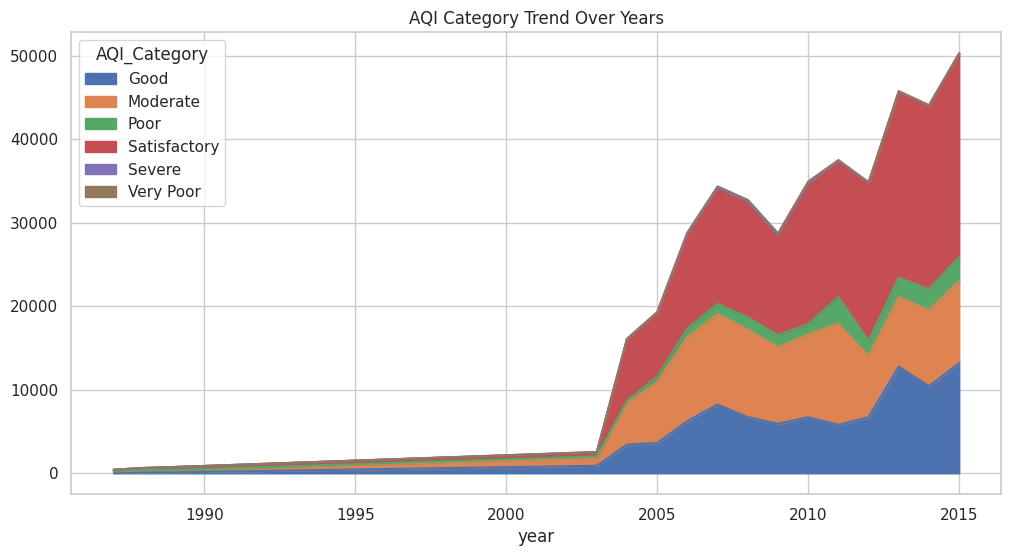

In [ ]:
category_trend = df.groupby(['year','AQI_Category']).size().unstack()

category_trend.plot(kind='area', stacked=True, figsize=(12,6))
plt.title("AQI Category Trend Over Years")
plt.show()

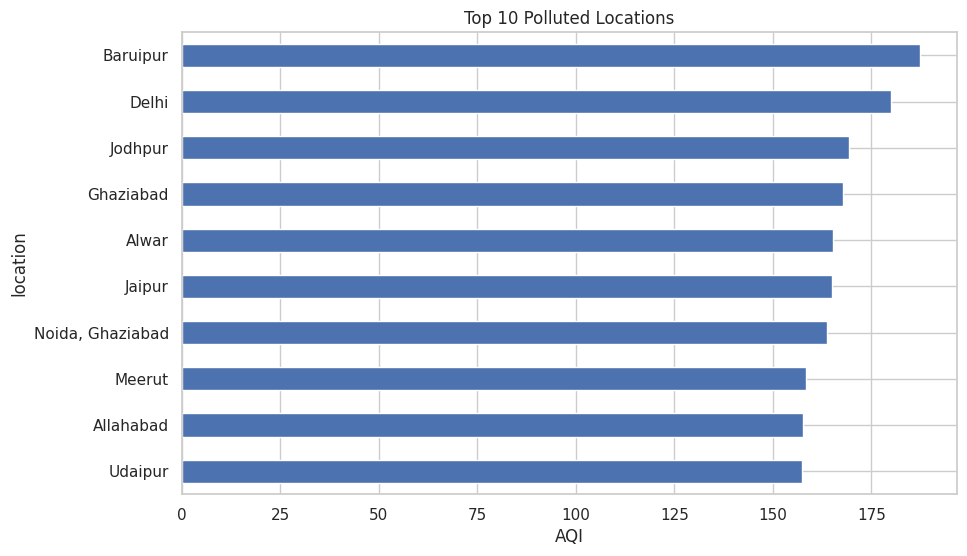

In [ ]:
top_locations = df.groupby('location')['AQI'].mean().sort_values(ascending=False).head(10)

top_locations.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Polluted Locations")
plt.xlabel("AQI")
plt.show()

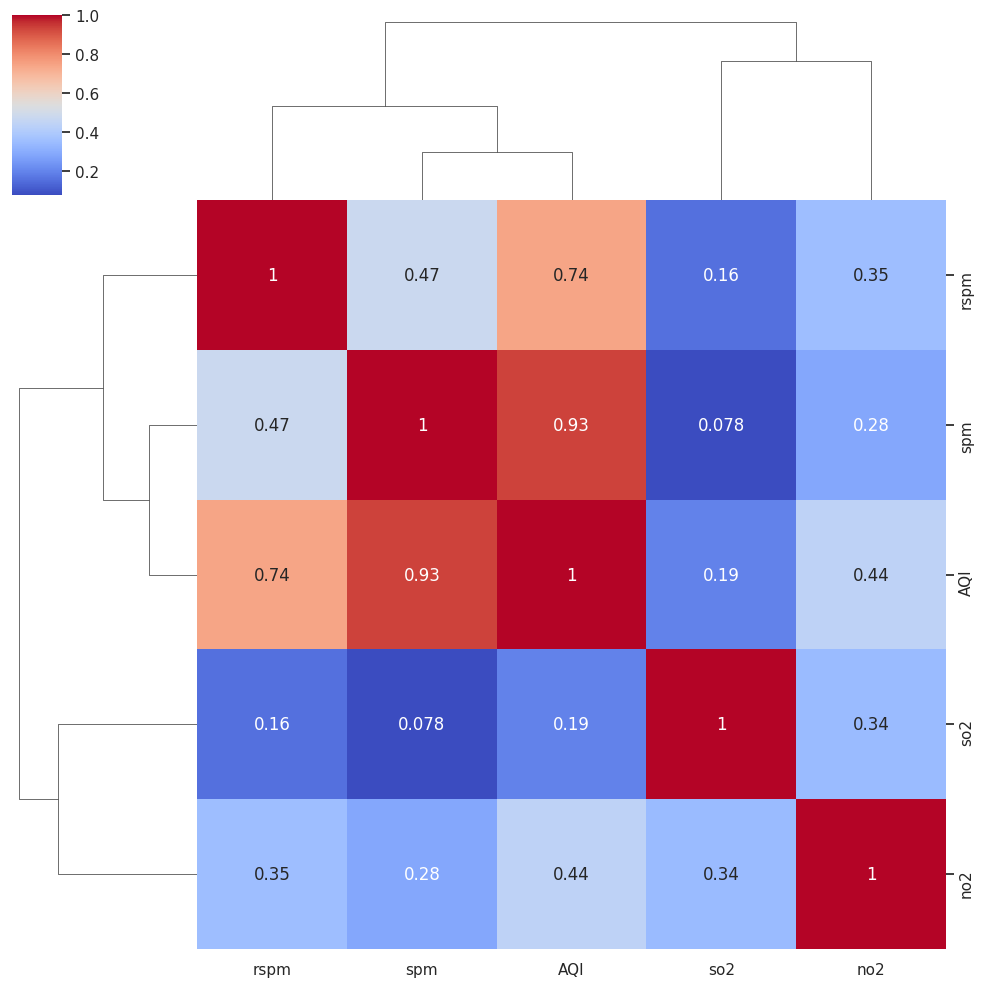

In [ ]:
sns.clustermap(df[['so2','no2','rspm','spm','AQI']].corr(), annot=True, cmap='coolwarm')